# 📗 Notebook 02 — AMNS (K-Means 3D): Seleção de *k*, Radar e Visualizações

**Melhorias desta versão:**
- 3D **colorido por cluster** com **legenda**;
- **Contagem de amostras por cluster** (tabela);
- **Silhouette média** impressa numericamente;
- Exporta **StandardScaler** junto do modelo (`joblib`).

**Objetivo:** escolher e **justificar** o melhor número de clusters (*k*) usando:  
`rtb_soma_centil`, `bens_imoveis`, `dividas_onus`.

**Entradas**:  
- `data/processed/distribuicao-renda-sample.csv`  
- `data/processed/metadata_preparo.json` (opcional; do Notebook 01)  
*(fallback: `data/processed/distribuicao-renda-clean.csv`)*

**Saídas**:  
- `data/processed/distribuicao-renda-sample_labeled.csv`  
- `data/processed/centroids_z.csv`, `data/processed/centroids.csv`  
- `data/processed/kmeans_bundle.joblib` (modelo + scaler + colunas)  
- PNGs dos gráficos em `data/processed/figs/`


## 1) Configuração & Parâmetros

In [16]:
%matplotlib inline
from __future__ import annotations
import json
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
import joblib

# Reprodutibilidade e pandas
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# Paths
ROOT = Path("..").resolve()
DATA_DIR = ROOT / "data"
PROC_DIR = DATA_DIR / "processed"
FIG_DIR  = PROC_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Parâmetros editáveis
K_RANGE = list(range(2, 11))         # k = 2..10
N_INIT = 20
MAX_ITER = 500
COLS = ['rtb_soma_centil', 'bens_imoveis', 'dividas_onus']

# Ajustes opcionais
USE_ROBUST_EXPERIMENT = False        # experimento paralelo com RobustScaler
BEST_K_OVERRIDE = None               # force um k final, se desejar

print("K_RANGE:", K_RANGE)
print("N_INIT, MAX_ITER:", N_INIT, MAX_ITER)
print("COLS:", COLS)
print("USE_ROBUST_EXPERIMENT:", USE_ROBUST_EXPERIMENT)

K_RANGE: [2, 3, 4, 5, 6, 7, 8, 9, 10]
N_INIT, MAX_ITER: 20 500
COLS: ['rtb_soma_centil', 'bens_imoveis', 'dividas_onus']
USE_ROBUST_EXPERIMENT: False


## 2) Carregamento & Checagens

In [17]:
# Tenta sample.csv e metadados; se não existir, usa clean.csv
sample_path = PROC_DIR / "distribuicao-renda-sample.csv"
clean_path  = PROC_DIR / "distribuicao-renda-clean.csv"
meta_path   = PROC_DIR / "metadata_preparo.json"

if sample_path.exists():
    df = pd.read_csv(sample_path)
    print("✓ Amostra carregada:", sample_path)
else:
    df = pd.read_csv(clean_path)
    print("⚠️ Amostra não encontrada; usando dataset limpo:", clean_path)

# Metadados (opcional)
metadata = {}
if meta_path.exists():
    with open(meta_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)
    print("✓ Metadados carregados:", meta_path)
    anos_escolhidos = metadata.get("anos_escolhidos", None)
    intervalo_centil = metadata.get("intervalo_centil", None)
    print("Anos escolhidos (NB01):", anos_escolhidos, "| Intervalo centil:", intervalo_centil)
else:
    print("⚠️ Metadados não encontrados. Prosseguindo sem metadata_preparo.json.")

# Checagens
missing = [c for c in COLS if c not in df.columns]
if missing:
    raise ValueError(f"Colunas ausentes na amostra/clean: {missing}")

# Remover linhas com NaN nessas colunas
before = len(df)
df = df.dropna(subset=COLS).reset_index(drop=True)
print(f"Removidas {before - len(df)} linhas com NaN nas colunas de interesse.")

print("Shape final para modelagem:", df.shape)
display(df[COLS].describe().T)

✓ Amostra carregada: C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\distribuicao-renda-sample.csv
✓ Metadados carregados: C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\metadata_preparo.json
Anos escolhidos (NB01): [2006, 2020] | Intervalo centil: [1, 50]
Removidas 81 linhas com NaN nas colunas de interesse.
Shape final para modelagem: (319, 24)


,count,mean,std,min,25%,50%,75%,max
rtb_soma_centil,319.0000,"12,976.4590","19,397.1018",0.0000,"1,662.5000","4,672.0000","14,096.0000","98,957.0000"
bens_imoveis,319.0000,"15,196.4908","20,916.4602",15.0000,"1,560.3350","5,655.0000","21,706.7600","98,027.0000"
dividas_onus,319.0000,"8,205.5037","15,247.9808",0.0000,293.0000,"1,985.2900","6,457.0000","92,845.0000"


## 3) Padronização (Z-score)

In [18]:
scaler = StandardScaler()
X = df[COLS].values
Xz = scaler.fit_transform(X)

# Guardar estatísticas para depois reverter centróides
means_ = scaler.mean_.copy()
scales_ = scaler.scale_.copy()

print("Means:", means_)
print("Scales:", scales_)

Means: [12976.45899687 15196.4907837   8205.50366771]
Scales: [19366.67494706 20883.64999983 15224.06236323]


## 4) (Opcional) Experimento paralelo com RobustScaler

In [19]:
if USE_ROBUST_EXPERIMENT:
    rscaler = RobustScaler()
    Xr = rscaler.fit_transform(X)
    print("RobustScaler ativo para experimento paralelo.")
else:
    Xr = None
    print("RobustScaler desligado (padrão).")

RobustScaler desligado (padrão).


## 5) Treino por *k* + coleta de métricas

In [20]:
results = {"k": [], "sse": [], "sil": [], "ch": [], "db": []}
models_by_k = {}
centroids_z_by_k = {}

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=N_INIT, max_iter=MAX_ITER, random_state=RANDOM_STATE)
    labels = km.fit_predict(Xz)
    models_by_k[k] = km
    centroids_z_by_k[k] = km.cluster_centers_
    results["k"].append(k)
    results["sse"].append(float(km.inertia_))
    results["sil"].append(float(silhouette_score(Xz, labels)))
    results["ch"].append(float(calinski_harabasz_score(Xz, labels)))
    results["db"].append(float(davies_bouldin_score(Xz, labels)))

res_df = pd.DataFrame(results)
display(res_df)

,k,sse,sil,ch,db
0,2,607.6178,0.6020,182.2760,0.9758
1,3,362.7486,0.5835,258.8342,0.8524
2,4,223.5023,0.6220,344.5928,0.6492
3,5,176.6254,0.5689,346.8323,0.7375
4,6,153.8397,0.5602,326.8196,0.8633
5,7,132.4404,0.5707,323.7464,0.8221
6,8,112.5414,0.4707,333.3716,0.8674
7,9,97.4158,0.4804,341.9251,0.8516
8,10,84.4202,0.4889,354.8746,0.7940


## 6) Curvas de seleção de *k* (Elbow/Métricas)

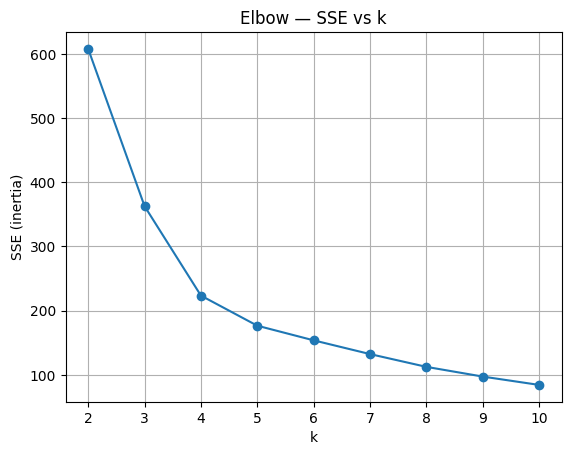

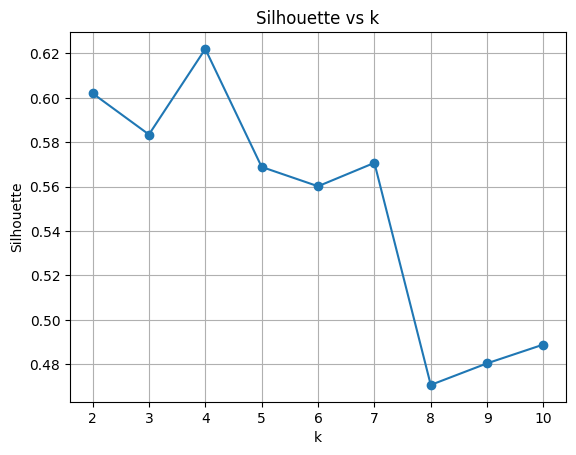

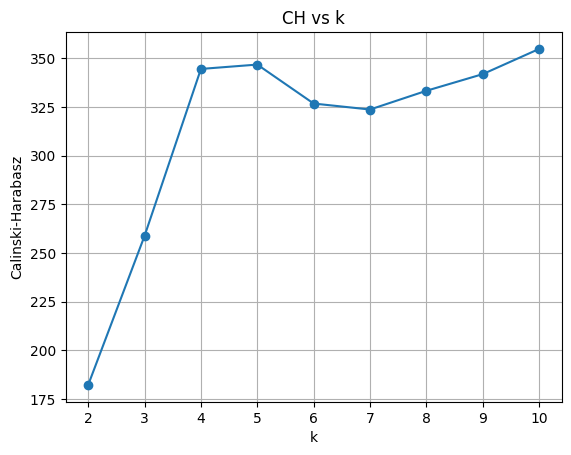

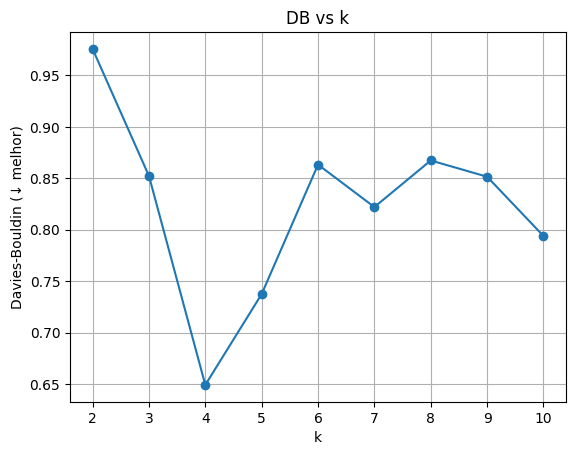

In [21]:
# SSE (Elbow)
plt.figure()
plt.plot(res_df["k"], res_df["sse"], marker="o")
plt.xlabel("k"); plt.ylabel("SSE (inertia)"); plt.title("Elbow — SSE vs k")
plt.grid(True); plt.savefig((FIG_DIR / "k_selection_sse.png"), dpi=150, bbox_inches="tight")
plt.show()

# Silhouette
plt.figure()
plt.plot(res_df["k"], res_df["sil"], marker="o")
plt.xlabel("k"); plt.ylabel("Silhouette"); plt.title("Silhouette vs k")
plt.grid(True); plt.savefig((FIG_DIR / "k_selection_silhouette.png"), dpi=150, bbox_inches="tight")
plt.show()

# Calinski-Harabasz
plt.figure()
plt.plot(res_df["k"], res_df["ch"], marker="o")
plt.xlabel("k"); plt.ylabel("Calinski-Harabasz"); plt.title("CH vs k")
plt.grid(True); plt.savefig((FIG_DIR / "k_selection_ch.png"), dpi=150, bbox_inches="tight")
plt.show()

# Davies-Bouldin
plt.figure()
plt.plot(res_df["k"], res_df["db"], marker="o")
plt.xlabel("k"); plt.ylabel("Davies-Bouldin (↓ melhor)"); plt.title("DB vs k")
plt.grid(True); plt.savefig((FIG_DIR / "k_selection_db.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7) Gráficos de teia (radar) para comparar *k*

As quatro métricas são normalizadas para **[0,1]** e alinhadas no sentido "**maior é melhor**":
- `SSE_norm = 1 - minmax(SSE)`  
- `Silhouette_norm = minmax(Silhouette)`  
- `CH_norm = minmax(CH)`  
- `DB_norm = 1 - minmax(DB)`  

Também calculamos um **score composto** (média simples das 4) para sugerir um k.

,k,SSE_n,Sil_n,CH_n,DB_n,score_composto
0,2,0.0000,0.8679,0.0000,0.0000,0.2170
1,3,0.4680,0.7453,0.4436,0.3779,0.5087
2,4,0.7342,1.0000,0.9404,1.0000,0.9186
3,5,0.8238,0.6488,0.9534,0.7297,0.7889
4,6,0.8673,0.5913,0.8375,0.3443,0.6601
5,7,0.9082,0.6609,0.8196,0.4706,0.7148
6,8,0.9463,0.0000,0.8754,0.3320,0.5384
7,9,0.9752,0.0643,0.9250,0.3804,0.5862
8,10,1.0000,0.1203,1.0000,0.5568,0.6693


k selecionado: 4


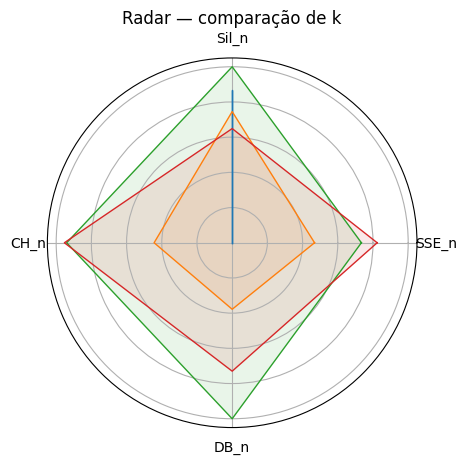

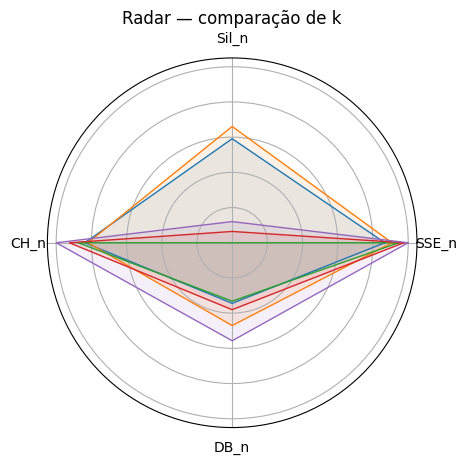

In [22]:
def minmax(x):
    x = np.array(x, dtype=float)
    if x.max() == x.min():
        return np.ones_like(x)
    return (x - x.min()) / (x.max() - x.min())

SSE_n = 1 - minmax(res_df["sse"])
SIL_n = minmax(res_df["sil"])
CH_n  = minmax(res_df["ch"])
DB_n  = 1 - minmax(res_df["db"])

radar_df = pd.DataFrame({
    "k": res_df["k"],
    "SSE_n": SSE_n, "Sil_n": SIL_n, "CH_n": CH_n, "DB_n": DB_n
})
radar_df["score_composto"] = radar_df[["SSE_n","Sil_n","CH_n","DB_n"]].mean(axis=1)
display(radar_df)

# Escolha automática (salva em best_k)
BEST_K_OVERRIDE = BEST_K_OVERRIDE if (BEST_K_OVERRIDE is not None and int(BEST_K_OVERRIDE) in list(radar_df["k"])) else None
best_k = int(BEST_K_OVERRIDE) if BEST_K_OVERRIDE is not None else int(radar_df.loc[radar_df["score_composto"].idxmax(), "k"])
print("k selecionado:", best_k)

# Radar para conjuntos de ks (divide em 2 se muitos)
def plot_radar_for_ks(df_norm: pd.DataFrame, ks: List[int], fname: Path):
    labels = ["SSE_n", "Sil_n", "CH_n", "DB_n"]
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]
    plt.figure()
    ax = plt.subplot(111, polar=True)
    for k in ks:
        row = df_norm.loc[df_norm["k"] == k, labels].values.flatten().tolist()
        row += row[:1]
        ax.plot(angles, row, linewidth=1)
        ax.fill(angles, row, alpha=0.1)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels); ax.set_yticklabels([])
    ax.set_title("Radar — comparação de k")
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

ks_all = radar_df["k"].tolist()
mid = max(2, len(ks_all)//2)
plot_radar_for_ks(radar_df, ks_all[:mid], (FIG_DIR / "radar_k_part1.png"))
plot_radar_for_ks(radar_df, ks_all[mid:], (FIG_DIR / "radar_k_part2.png"))

## 8) Decisão: escolha do *k*

In [23]:
print("k final escolhido:", best_k)

k final escolhido: 4


## 9) Treino final e centróides (z-score e escala original)

In [24]:
km_final = KMeans(n_clusters=best_k, n_init=N_INIT, max_iter=MAX_ITER, random_state=RANDOM_STATE)
labels_final = km_final.fit_predict(Xz)
centroids_z = km_final.cluster_centers_
centroids   = scaler.inverse_transform(centroids_z)

df_labeled = df.copy()
df_labeled["cluster"] = labels_final

print("Centróides (z-score):")
display(pd.DataFrame(centroids_z, columns=COLS).round(3))
print("Centróides (escala original):")
display(pd.DataFrame(centroids, columns=COLS).round(3))

# Tamanho de cada cluster
print("Tamanho de cada cluster:")
display(df_labeled["cluster"].value_counts().sort_index().rename("count").to_frame())

Centróides (z-score):


,rtb_soma_centil,bens_imoveis,dividas_onus
0,-0.3890,-0.3740,-0.4220
1,2.7710,-0.6190,1.2900
2,0.2500,1.8080,-0.0770
3,-0.3370,-0.5090,2.8180


Centróides (escala original):


,rtb_soma_centil,bens_imoveis,dividas_onus
0,"5,443.8660","7,387.7140","1,779.8600"
1,"66,633.1850","2,269.9200","27,840.9740"
2,"17,814.2370","52,953.9150","7,037.5420"
3,"6,440.7090","4,567.4430","51,109.7140"


Tamanho de cada cluster:


,count
cluster,
0,212
1,27
2,59
3,21


## 10) Visualizações do modelo final

### 10.1) Silhouette plot

Silhouette média (k=4): 0.622


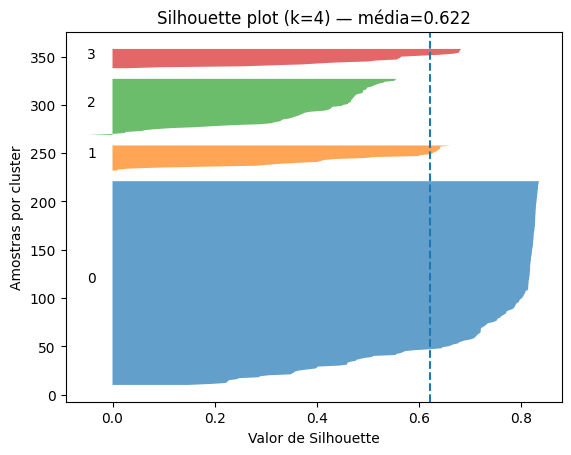

In [25]:
from matplotlib import cm

sil_vals = silhouette_samples(Xz, labels_final)
sil_avg  = silhouette_score(Xz, labels_final)
print(f"Silhouette média (k={best_k}): {sil_avg:.3f}")

y_lower = 10
plt.figure()
for i in range(best_k):
    ith_sil_vals = sil_vals[labels_final == i]
    ith_sil_vals.sort()
    size_i = ith_sil_vals.shape[0]
    y_upper = y_lower + size_i
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil_vals, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=sil_avg, linestyle="--")
plt.xlabel("Valor de Silhouette")
plt.ylabel("Amostras por cluster")
plt.title(f"Silhouette plot (k={best_k}) — média={sil_avg:.3f}")
plt.savefig((FIG_DIR / f"silhouette_k{best_k}.png"), dpi=150, bbox_inches="tight")
plt.show()

### 10.2) Dispersão 3D dos clusters (colorido por cluster)

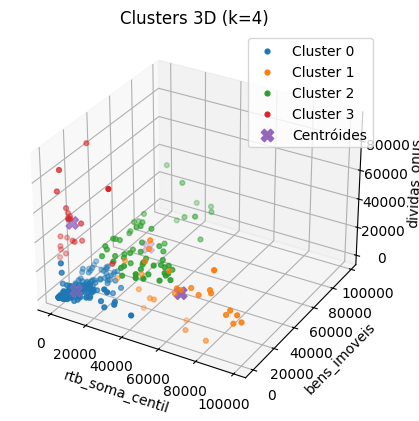

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

handles = []
labels_leg = []
for i in range(best_k):
    part = df_labeled[df_labeled["cluster"] == i]
    h = ax.scatter(part[COLS[0]], part[COLS[1]], part[COLS[2]], s=12)
    handles.append(h)
    labels_leg.append(f"Cluster {i}")

# Centr&oacute;ides
hc = ax.scatter(centroids[:,0], centroids[:,1], centroids[:,2], s=80, marker='X')
handles.append(hc); labels_leg.append("Centróides")

ax.set_xlabel(COLS[0]); ax.set_ylabel(COLS[1]); ax.set_zlabel(COLS[2])
ax.set_title(f"Clusters 3D (k={best_k})")
ax.legend(handles, labels_leg, loc="best")
plt.savefig((FIG_DIR / f"clusters3d_k{best_k}.png"), dpi=150, bbox_inches="tight")
plt.show()

### 10.3) Radar de perfil por cluster (z-score das médias por cluster)

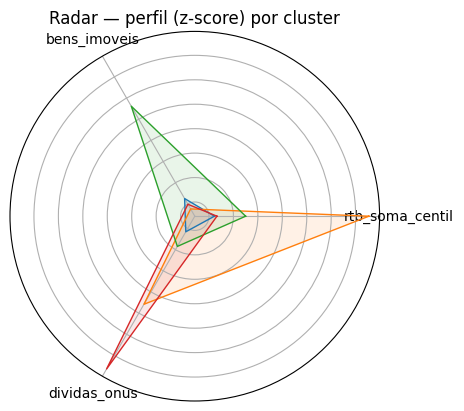

In [27]:
Z_df = pd.DataFrame(Xz, columns=COLS)
Z_df["cluster"] = labels_final
means_z_by_cluster = Z_df.groupby("cluster")[COLS].mean().reset_index()

labels_axes = COLS
angles = np.linspace(0, 2*np.pi, len(labels_axes), endpoint=False).tolist()
angles += angles[:1]

plt.figure()
ax = plt.subplot(111, polar=True)
for i in range(best_k):
    row = means_z_by_cluster.loc[means_z_by_cluster["cluster"]==i, COLS].values.flatten().tolist()
    row += row[:1]
    ax.plot(angles, row, linewidth=1)
    ax.fill(angles, row, alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_axes)
ax.set_yticklabels([])
ax.set_title("Radar — perfil (z-score) por cluster")
plt.savefig((FIG_DIR / f"radar_clusters_k{best_k}.png"), dpi=150, bbox_inches="tight")
plt.show()

### 10.4) Heatmap de centróides (z-score)

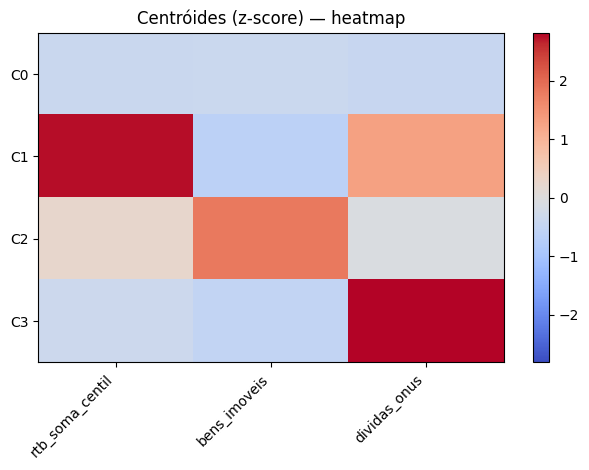

In [28]:
plt.figure()
v = np.max(np.abs(centroids_z))
plt.imshow(centroids_z, aspect='auto', cmap='coolwarm', vmin=-v, vmax=v)
plt.colorbar()
plt.yticks(range(best_k), [f"C{i}" for i in range(best_k)])
plt.xticks(range(len(COLS)), COLS, rotation=45, ha='right')
plt.title("Centróides (z-score) — heatmap")
plt.tight_layout()
plt.savefig((FIG_DIR / f"heatmap_centroids_z_k{best_k}.png"), dpi=150, bbox_inches="tight")
plt.show()

## 11) Sanidade & Estabilidade (rápido)

In [29]:
seeds = [RANDOM_STATE, RANDOM_STATE+1, RANDOM_STATE+2]
metrics_rows = []
base_labels = labels_final

for rs in seeds:
    km_tmp = KMeans(n_clusters=best_k, n_init=N_INIT, max_iter=MAX_ITER, random_state=rs)
    labels_tmp = km_tmp.fit_predict(Xz)
    sil_tmp = silhouette_score(Xz, labels_tmp)
    ari_tmp = adjusted_rand_score(base_labels, labels_tmp)
    metrics_rows.append({"seed": rs, "inertia": float(km_tmp.inertia_), "silhouette": float(sil_tmp), "ARI_vs_base": float(ari_tmp)})

stability_df = pd.DataFrame(metrics_rows)
print("Estabilidade (variações de seed):")
display(stability_df)

Estabilidade (variações de seed):


,seed,inertia,silhouette,ARI_vs_base
0,42,223.5023,0.6220,1.0000
1,43,223.5023,0.6220,1.0000
2,44,223.5023,0.6220,1.0000


## 12) Export & Logging

In [30]:
labeled_path   = PROC_DIR / "distribuicao-renda-sample_labeled.csv"
centroids_z_fp = PROC_DIR / "centroids_z.csv"
centroids_fp   = PROC_DIR / "centroids.csv"
bundle_fp      = PROC_DIR / "kmeans_bundle.joblib"

# CSVs
df_labeled.to_csv(labeled_path, index=False, encoding="utf-8")
pd.DataFrame(centroids_z, columns=COLS).to_csv(centroids_z_fp, index=False, encoding="utf-8")
pd.DataFrame(centroids,   columns=COLS).to_csv(centroids_fp, index=False, encoding="utf-8")

# Bundle (modelo + scaler + metainfo)
bundle = {
    "model": km_final,
    "scaler": scaler,
    "cols": COLS,
    "k": int(best_k),
    "means": means_.tolist(),
    "scales": scales_.tolist(),
}
joblib.dump(bundle, bundle_fp)

print("Arquivos salvos:")
print("-", labeled_path.resolve())
print("-", centroids_z_fp.resolve())
print("-", centroids_fp.resolve())
print("-", bundle_fp.resolve())
print("-", (FIG_DIR / "k_selection_sse.png").resolve())
print("-", (FIG_DIR / "k_selection_silhouette.png").resolve())
print("-", (FIG_DIR / "k_selection_ch.png").resolve())
print("-", (FIG_DIR / "k_selection_db.png").resolve())
print("-", (FIG_DIR / "radar_k_part1.png").resolve())
print("-", (FIG_DIR / "radar_k_part2.png").resolve())
print("-", (FIG_DIR / f"silhouette_k{best_k}.png").resolve())
print("-", (FIG_DIR / f"clusters3d_k{best_k}.png").resolve())
print("-", (FIG_DIR / f"radar_clusters_k{best_k}.png").resolve())
print("-", (FIG_DIR / f"heatmap_centroids_z_k{best_k}.png").resolve())

Arquivos salvos:
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\distribuicao-renda-sample_labeled.csv
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\centroids_z.csv
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\centroids.csv
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\kmeans_bundle.joblib
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\figs\k_selection_sse.png
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\figs\k_selection_silhouette.png
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\figs\k_selection_ch.png
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\figs\k_selection_db.png
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\figs\radar_k_part1.png
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\figs\radar_k_part2.png
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\figs\silhouette_k4.png
- C:\Users\96207

## 13) Sumário & Próximos passos
- Selecionamos *k* a partir de múltiplas métricas (SSE, Silhouette, CH, DB) e **radar** (score composto).  
- Visualizações finais com **3D colorido por cluster**, **Silhouette média** explícita, **radar de perfil** e **heatmap**.  
- Exportamos amostra rotulada, centróides e um **bundle** (`joblib`) com **modelo + scaler**.

**Sugestões de aula**: comente *por que* padronizamos, como ler o **radar** (métricas no mesmo sentido), e mostre o **perfil z-score** de cada cluster para interpretá-los.


## 11b) Composição por **ano** e por **UF** (contagens)

In [31]:
# Tabelas de contagem por cluster × ano e cluster × UF
from pathlib import Path

tables = {}

if 'ano' in df_labeled.columns:
    cxa = df_labeled.groupby(['cluster','ano']).size().unstack(fill_value=0)
    print("Contagem por cluster × ano:")
    display(cxa)
    tables['cluster_counts_por_ano'] = cxa
else:
    print("Coluna 'ano' não encontrada em df_labeled; pulando tabela por ano.")

if 'uf' in df_labeled.columns:
    cxu = df_labeled.groupby(['cluster','uf']).size().unstack(fill_value=0)
    print("Contagem por cluster × UF:")
    display(cxu)
    tables['cluster_counts_por_uf'] = cxu
else:
    print("Coluna 'uf' não encontrada em df_labeled; pulando tabela por UF.")

Contagem por cluster × ano:


ano,2006,2020
cluster,,
0,109,103
1,0,27
2,24,35
3,9,12


Contagem por cluster × UF:


uf,AC,AL,AM,AP,BA,BRASIL,CE,DF,ES,GO,MA,MG,MS,MT,PA,PB,PE,PI,PR,RJ,RN,RO,RR,RS,SC,SE,SP,TO
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,17,2,12,15,5,7,5,4,7,11,9,0,13,3,8,11,14,10,2,4,7,9,12,1,6,4,5,9
1,0,0,0,0,1,0,0,0,0,0,0,4,0,0,0,0,0,0,7,6,0,0,0,4,4,0,1,0
2,0,0,0,0,7,0,2,4,3,5,0,8,7,3,2,0,2,0,6,6,0,0,0,4,0,0,0,0
3,0,0,0,0,0,7,0,1,0,0,0,4,0,0,1,0,0,0,2,0,0,0,0,3,1,0,2,0


## 11c) Perfis por cluster (escala original e z-score) + Silhouette média por cluster

In [32]:
# Perfis em escala original
means_orig_by_cluster = df_labeled.groupby('cluster')[COLS].mean().reset_index()
print("Perfis por cluster — escala ORIGINAL (médias):")
display(means_orig_by_cluster)

# Perfis em z-score (recalcula se necessário)
try:
    means_z_by_cluster
except NameError:
    Z_df = pd.DataFrame(Xz, columns=COLS)
    Z_df['cluster'] = labels_final
    means_z_by_cluster = Z_df.groupby('cluster')[COLS].mean().reset_index()

print("Perfis por cluster — Z-SCORE (médias):")
display(means_z_by_cluster)

# Silhouette média por cluster
from sklearn.metrics import silhouette_samples
sil_vals = silhouette_samples(Xz, labels_final)
sil_df = pd.DataFrame({'cluster': labels_final, 'sil': sil_vals})
sil_mean_by_cluster = sil_df.groupby('cluster')['sil'].mean().rename('silhouette_media').reset_index()
print("Silhouette média por cluster:")
display(sil_mean_by_cluster)

Perfis por cluster — escala ORIGINAL (médias):


,cluster,rtb_soma_centil,bens_imoveis,dividas_onus
0,0,"5,443.8658","7,387.7143","1,779.8603"
1,1,"66,633.1852","2,269.9196","27,840.9737"
2,2,"17,814.2373","52,953.9153","7,037.5424"
3,3,"6,440.7086","4,567.4429","51,109.7143"


Perfis por cluster — Z-SCORE (médias):


,cluster,rtb_soma_centil,bens_imoveis,dividas_onus
0,0,-0.3889,-0.3739,-0.4221
1,1,2.7706,-0.6190,1.2898
2,2,0.2498,1.8080,-0.0767
3,3,-0.3375,-0.5090,2.8182


Silhouette média por cluster:


,cluster,silhouette_media
0,0,0.7262
1,1,0.4379
2,2,0.3758
3,3,0.4990


## 12b) Export extra das tabelas (para slides/relatório)

In [33]:
# Salvar tabelas adicionais
extra_paths = []

# Diretório de saída já definido (PROC_DIR)
if 'cluster_counts_por_ano' in locals().get('tables', {}):
    p = PROC_DIR / "cluster_counts_por_ano.csv"
    tables['cluster_counts_por_ano'].to_csv(p, encoding='utf-8')
    extra_paths.append(p.resolve())

if 'cluster_counts_por_uf' in locals().get('tables', {}):
    p = PROC_DIR / "cluster_counts_por_uf.csv"
    tables['cluster_counts_por_uf'].to_csv(p, encoding='utf-8')
    extra_paths.append(p.resolve())

p = PROC_DIR / "cluster_profiles_original.csv"
means_orig_by_cluster.to_csv(p, index=False, encoding='utf-8')
extra_paths.append(p.resolve())

p = PROC_DIR / "cluster_profiles_z.csv"
means_z_by_cluster.to_csv(p, index=False, encoding='utf-8')
extra_paths.append(p.resolve())

p = PROC_DIR / "silhouette_media_por_cluster.csv"
sil_mean_by_cluster.to_csv(p, index=False, encoding='utf-8')
extra_paths.append(p.resolve())

print("Arquivos extras salvos:")
for path in extra_paths:
    print("-", path)

Arquivos extras salvos:
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\cluster_counts_por_ano.csv
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\cluster_counts_por_uf.csv
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\cluster_profiles_original.csv
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\cluster_profiles_z.csv
- C:\Users\96207159187\Desktop\kmeans-3d-cluster\data\processed\silhouette_media_por_cluster.csv
